## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.

- 이미지를 문장처럼 패치 단위의 시퀀스로 변환하여 처리하는 모델이다. 이미지를 일정 크기의 작은 조각들로 나눈 뒤, 각 패치를 벡터로 변환하여 Transformer 구조의 입력으로 사용한다. 또한, 위치 정보를 잃지 않기 위해 Position Embedding을 추가하고 Self-Attention을 통해 각 패치 간의 관계를 전역적으로 학습한다.
- CNN은 상대적으로 적은 데이터에서도 안정적인 학습이 가능하지만, ViT는 학습 파라미터 수가 많아 대규모 데이터셋을 통한 사전학습이 필요하고, 이후에 맞게 fine-tuning한다.

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [1]:
!curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
!python pytorch-xla-env-setup.py --version 1.7
!pip install timm
!pip install torch_xla

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     68      0 --:--:-- --:--:-- --:--:--    68
  File "/content/pytorch-xla-env-setup.py", line 1
    404: Not Found
    ^^^
SyntaxError: illegal target for annotation
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 MB 10.4 MB/s eta 0:00:00


### 데이터 불러오기

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip "/content/drive/MyDrive/train_images.zip"

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: 3952546193.jpg          
  inflating: 3952799769.jpg          
  inflating: 3953140534.jpg          
  inflating: 3953222407.jpg          
  inflating: 3953247024.jpg          
  inflating: 3953327881.jpg          
  inflating: 3953331047.jpg          
  inflating: 3953514366.jpg          
  inflating: 3953530273.jpg          
  inflating: 3953560426.jpg          
  inflating: 3953648207.jpg          
  inflating: 3953857113.jpg          
  inflating: 3953901317.jpg          
  inflating: 3954180556.jpg          
  inflating: 3954239221.jpg          
  inflating: 3954387963.jpg          
  inflating: 3954399974.jpg          
  inflating: 3954487465.jpg          
  inflating: 3954910918.jpg          
  inflating: 3955391972.jpg          
  inflating: 3955442838.jpg          
  inflating: 3955739563.jpg          
  inflating: 3955931830.jpg          
  inflating: 3955972139.jpg          
  inflating: 3956075690.jpg          
  inflating: 3

In [4]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip "/content/drive/MyDrive/jx_vit_base_p16_224-80ecf9dd.pth.zip"

Archive:  /content/drive/MyDrive/jx_vit_base_p16_224-80ecf9dd.pth.zip
  inflating: jx_vit_base_p16_224-80ecf9dd.pth  


In [5]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive/"
TRAIN_PATH = "/content/drive/MyDrive/train_images"
TEST_PATH = "/content/drive/MyDrive/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/jx_vit_base_p16_224-80ecf9dd.pth"
)

### 라이브러리

In [6]:
# ==== 기본 패키지 ====
import os
import gc
import time
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")

from PIL import Image

# tqdm (노트북/코랩 호환)
try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

# ==== PyTorch ====
import torch
import torch.nn as nn
import torchvision.transforms as transforms

# ==== torch_xla (TPU) : 가능할 때만 사용 ====
USE_XLA = False
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.xla_multiprocessing as xmp
    import torch_xla.distributed.parallel_loader as pl
    USE_XLA = True
except Exception:
    # TPU 환경이 아니거나 버전 불일치면 조용히 건너뜀
    USE_XLA = False

# ==== timm : 없으면 자동 설치 후 임포트 ====
try:
    import timm
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

# ==== scikit-learn ====
from sklearn import model_selection, metrics

# ==== 디바이스 설정 ====
if USE_XLA:
    try:
        device = xm.xla_device()
    except Exception:
        # XLA 임포트는 됐지만 디바이스 초기화 실패 시 CUDA/CPU로 폴백
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        USE_XLA = False
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device} | USE_XLA={USE_XLA} | CUDA available={torch.cuda.is_available()}")

# ==== 재현성(선택) ====
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

/usr/local/lib/python3.12/dist-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


Device: xla:0 | USE_XLA=True | CUDA available=False


/tmp/ipython-input-752637725.py:52: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


In [7]:
os.environ["XLA_USE_BF16"] = "1"
os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [8]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [9]:
IMG_SIZE = 224  #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 16
LR = 2e-05
GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [10]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

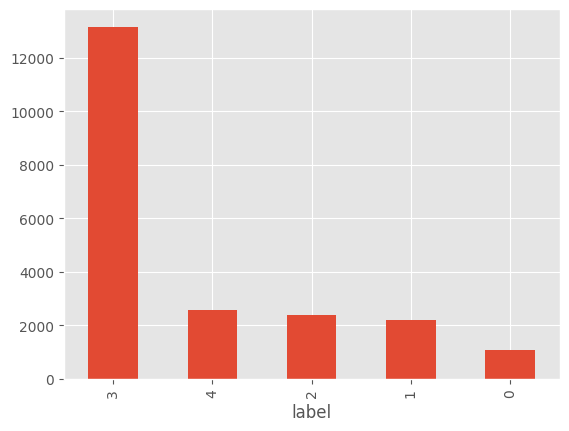

In [12]:
df.label.value_counts().plot(kind="bar")

In [13]:
# train과 test를 9:1로 나눠주세요.
# random_state은 자유롭게 지정 가능합니다.
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.1, random_state=42, stratify=df.label.values
)

In [14]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, data_path=DATA_PATH, mode="train", transforms=None):
        super().__init__()
        self.df_data = df.values
        self.data_path = data_path
        self.transforms = transforms
        self.mode = mode
        self.data_dir = "train_images" if mode == "train" else "test_images"

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.data_path, self.data_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [15]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [16]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [17]:
# 이 셀 안의 코드에 대해서 주석을 달아주세요.
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):
        # nn.Module의 초기화자를 호출하여 PyTorch 모듈로서의 기본 구성 요소를 세팅
        super(ViTBase16, self).__init__()
        # timm 라이브러리로 사전정의된 ViT(B/16, 입력 224) 모델을 생성
        # pretrained=False: timm의 ImageNet 사전학습 가중치를 바로 쓰지 않겠다는 의미
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False)
        # 사용자가 전달한 pretrained 플래그가 True면, 외부에서 저장한 가중치(MODEL_PATH)를 불러와 로드

        if pretrained:
            self.model.load_state_dict(torch.load(MODEL_PATH))
        # 분류기 헤드(최종 선형층)를 현재 과제의 클래스 개수(n_classes)에 맞게 교체
        # self.model.head.in_features: ViT의 분류 헤드 입력 차원을 읽어옴
        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    def forward(self, x):
        # 입력 텐서 x를 timm 모델에 통과시켜 logits을 얻음
        x = self.model(x)
        # 분류 작업에서의 최종 출력(클래스별 logit)을 반환
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        # 한 에포크 동안의 누적 손실과 정확도를 저장할 변수 초기화
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        # 학습 모드로 전환(드롭아웃/배치정규화 등 학습 동작 활성화)
        self.model.train()
        # 배치 단위로 학습 데이터 순회(i: 배치 인덱스, (data, target): 입력과 정답 라벨)
        for i, (data, target) in enumerate(train_loader):
            # CUDA 환경일 때는 텐서를 GPU 메모리로 이동
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
                # XLA(TPU) 환경일 때는 XLA 디바이스로 이동하고 dtype/타입을 명시
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            # 이전 스텝의 기울기(gradient) 값을 0으로 초기화
            optimizer.zero_grad()
            # 모델 순전파를 통해 예측값(로짓) 계산
            output = self.forward(data)
            # 손실 함수를 이용해 손실(loss) 계산
            loss = criterion(output, target)
            # 손실에 대한 역전파로 가중치에 대한 기울기 계산
            loss.backward()
            # 배치 정확도: argmax로 예측 클래스 뽑고, 정답과 비교 후 평균
            accuracy = (output.argmax(dim=1) == target).float().mean()

            # 에포크 누적 손실/정확도에 현재 배치 값을 더함(나중에 배치 수로 평균)
            epoch_loss += loss
            epoch_accuracy += accuracy

            # XLA(TPU)에서는 xm.optimizer_step을 사용해 실제 스텝을 적용해야 함
            if device.type == "xla":
                xm.optimizer_step(optimizer)

                 # TPU 학습 시 마스터 프로세스에서만 주기적으로 로그 출력(매 20배치마다)
                if i % 20 == 0:
                    xm.master_print(f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss}")

            else:
                optimizer.step()

        # 에포크 평균 손실과 평균 정확도 반환(누적값을 배치 수로 나눔)
        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    def validate_one_epoch(self, valid_loader, criterion, device):
        valid_loss = 0.0
        valid_accuracy = 0.0

        self.model.eval()
        # 검증 데이터셋을 배치 단위로 순회
        for data, target in valid_loader:
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            # 검증 단계에서는 기울기 계산이 필요 없으므로 no_grad 컨텍스트 사용
            with torch.no_grad():
                output = self.model(data)
                loss = criterion(output, target)
                accuracy = (output.argmax(dim=1) == target).float().mean()

                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [18]:
def fit_tpu(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        para_train_loader = pl.ParallelLoader(train_loader, [device])

        xm.master_print(f"{'='*50}")
        xm.master_print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            para_train_loader.per_device_loader(device), criterion, optimizer, device
        )
        xm.master_print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            gc.collect()
            para_valid_loader = pl.ParallelLoader(valid_loader, [device])
            xm.master_print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(
                para_valid_loader.per_device_loader(device), criterion, device
            )
            xm.master_print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)
            gc.collect()

            if valid_loss <= valid_loss_min and epoch != 1:
                xm.master_print(
                    "Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [19]:
model = ViTBase16(n_classes=5, pretrained=False)

In [20]:
def _run():
    train_dataset = CassavaDataset(train_df, mode="train", transforms=transforms_train)
    valid_dataset = CassavaDataset(valid_df, mode="train", transforms=transforms_valid)

    train_sampler = torch.utils.data.distributed.DistributedSampler(
        train_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=True,
    )

    valid_sampler = torch.utils.data.distributed.DistributedSampler(
        valid_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=False,
    )

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        drop_last=True,
        num_workers=8,
    )

    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset,
        batch_size=BATCH_SIZE,
        sampler=valid_sampler,
        drop_last=True,
        num_workers=8,
    )

    criterion = nn.CrossEntropyLoss()  #cross entropy loss로 설정.
    device = xm.xla_device()
    model.to(device)

    lr = LR * xm.xrt_world_size()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    xm.master_print(f"INITIALIZING TRAINING ON {xm.xrt_world_size()} TPU CORES")
    start_time = datetime.now()
    xm.master_print(f"Start Time: {start_time}")

    logs = fit_tpu(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    xm.master_print(f"Execution time: {datetime.now() - start_time}")

    xm.master_print("Saving Model")
    xm.save(
        model.state_dict(), f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )

In [26]:
# Training 시작
def _mp_fn(rank, flags):
    torch.set_default_tensor_type("torch.FloatTensor")
    a = _run()


# Run
FLAGS = {}
xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=1, start_method="fork")

/tmp/ipython-input-2257378104.py:36: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


INITIALIZING TRAINING ON 1 TPU CORES
Start Time: 2025-11-09 07:48:55.248283
EPOCH 1 - TRAINING...


Exception in thread Thread-5 (_loader_worker):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch_xla/distributed/parallel_loader.py", line 165, in _loader_worker
    _, data = next(data_iter)
              ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 734, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1516, in _next_data
    return self._process_data(data, worker_id)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1551, in _process_data
    data.reraise()
  File "/usr/local/lib/python3.12/dist-packages/torch/


	[TRAIN] EPOCH 1 - LOSS: 0.0, ACCURACY: 0.0

EPOCH 1 - VALIDATING...
	[VALID] LOSS: 0.0, ACCURACY: 0.0

Execution time: 0:00:14.347591
Saving Model


Exception in thread Thread-7 (_loader_worker):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch_xla/distributed/parallel_loader.py", line 165, in _loader_worker
    _, data = next(data_iter)
              ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 734, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1516, in _next_data
    return self._process_data(data, worker_id)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1551, in _process_data
    data.reraise()
  File "/usr/local/lib/python3.12/dist-packages/torch/